In [21]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa
tau = 6.4*1e-13 # scattering time in seconds
from utils import hbar, c, alpha
euler_gamma = 0.57721

### This notebook re-creates some of the figures in the paper "Extraordinary optical reflection from sub-wavelength cylinder arrays" by Gomez-Medina

We note that $K_mD=2\pi m$ and $q_mD=\sqrt{(2\pi)^2(\omega D/(2\pi c))^2-(Q_0D-2\pi m)^2}$

In [140]:
def G_b_sum_term(x, m, Q_0_D = 0.8*pi): # x is omega*D/(2pi*c)
    K_m = 2*pi*m
    q_m_sqrd = (2*pi)**2*x**2-(Q_0_D-K_m)**2 + 0j
    q_minus_m_sqrd = (2*pi)**2*x**2-(Q_0_D+K_m)**2 + 0j
    return (1/2)*(1j/sqrt(q_m_sqrd) + 1j/sqrt(q_minus_m_sqrd) - 2/K_m)

def G_0_sum_term(x, m):
    K_m = 2*pi*m
    q_m_sqrd = (2*pi)**2*x**2-(Q_0_D-K_m)**2 + 0j
    return 1j/(2*sqrt(q_m_sqrd))

In [167]:
N = 100000
M = 100 # Number of reciprocal lattice sum terms
x_v = linspace(0.0001, 2, N) # omega*D/(2*pi*c)
G_b_v = zeros(N, dtype=complex)
Q_0_D = 0.8*pi
for (x_idx, x) in enumerate(x_v):
    G_b = 0
    G_b_zero_term = 1j/(2*sqrt((2*pi)**2*x**2-(Q_0_D)**2 + 0j))
    for m in range(1, M):
        G_b += G_b_sum_term(x, m)
    G_b += euler_gamma/(2*pi)
    G_b += log(x/2)/(2*pi)
    G_b += G_b_zero_term
    G_b += -1j/4
    G_b_v[x_idx] = G_b

In [168]:
epsilon_minus_one_term = 4/9*x_v**2
alpha_zz_inv = (1-1j*(pi/4)*epsilon_minus_one_term)/(pi*epsilon_minus_one_term)

### The plot below is Figure 2(a) of the paper

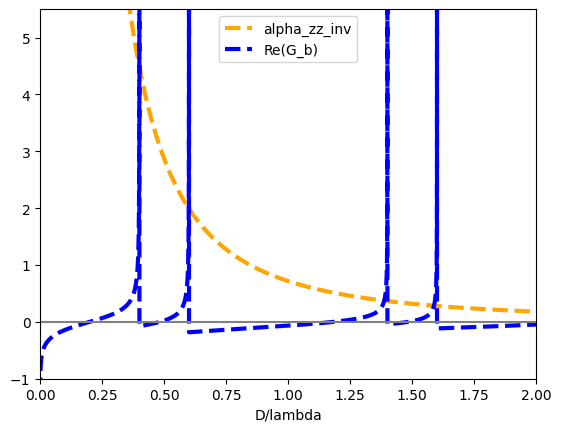

In [169]:
plt.plot(x_v, alpha_zz_inv.real, linestyle="dashed", color="orange", linewidth=3, label="alpha_zz_inv")
plt.plot(x_v, G_b_v.real, linestyle="dashed", color="blue", linewidth=3, label="Re(G_b)")
plt.hlines([0], 0, 2, color="Grey")
plt.ylim(-1, 5.5)
plt.xlim(0, 2)
plt.xlabel("D/lambda");
plt.legend();

### Now we find the reflectance

In [170]:
N = 100000
M = 20 # Number of reciprocal lattice sum terms
x_v = linspace(0.0001, 2, N) # omega*D/(2*pi*c)
G_0_v = zeros(N, dtype=complex)
for (x_idx, x) in enumerate(x_v):
    G_0 = 0
    for m in range(-M, M):
        G_0 += G_0_sum_term(x, m)
    G_0_v[x_idx] = G_0

In [180]:
G_0_v_imag = G_0_v.imag
R_term_2 = ((alpha_zz_inv - G_b_v).real)**2 + (G_0_v_imag)**2
R_term_1 = G_0_v_imag/(2*sqrt((2*pi)**2*x_v**2-(Q_0_D)**2 + 0j))
R_v = R_term_1/R_term_2

### The figure below is Figure 2(b) of the paper

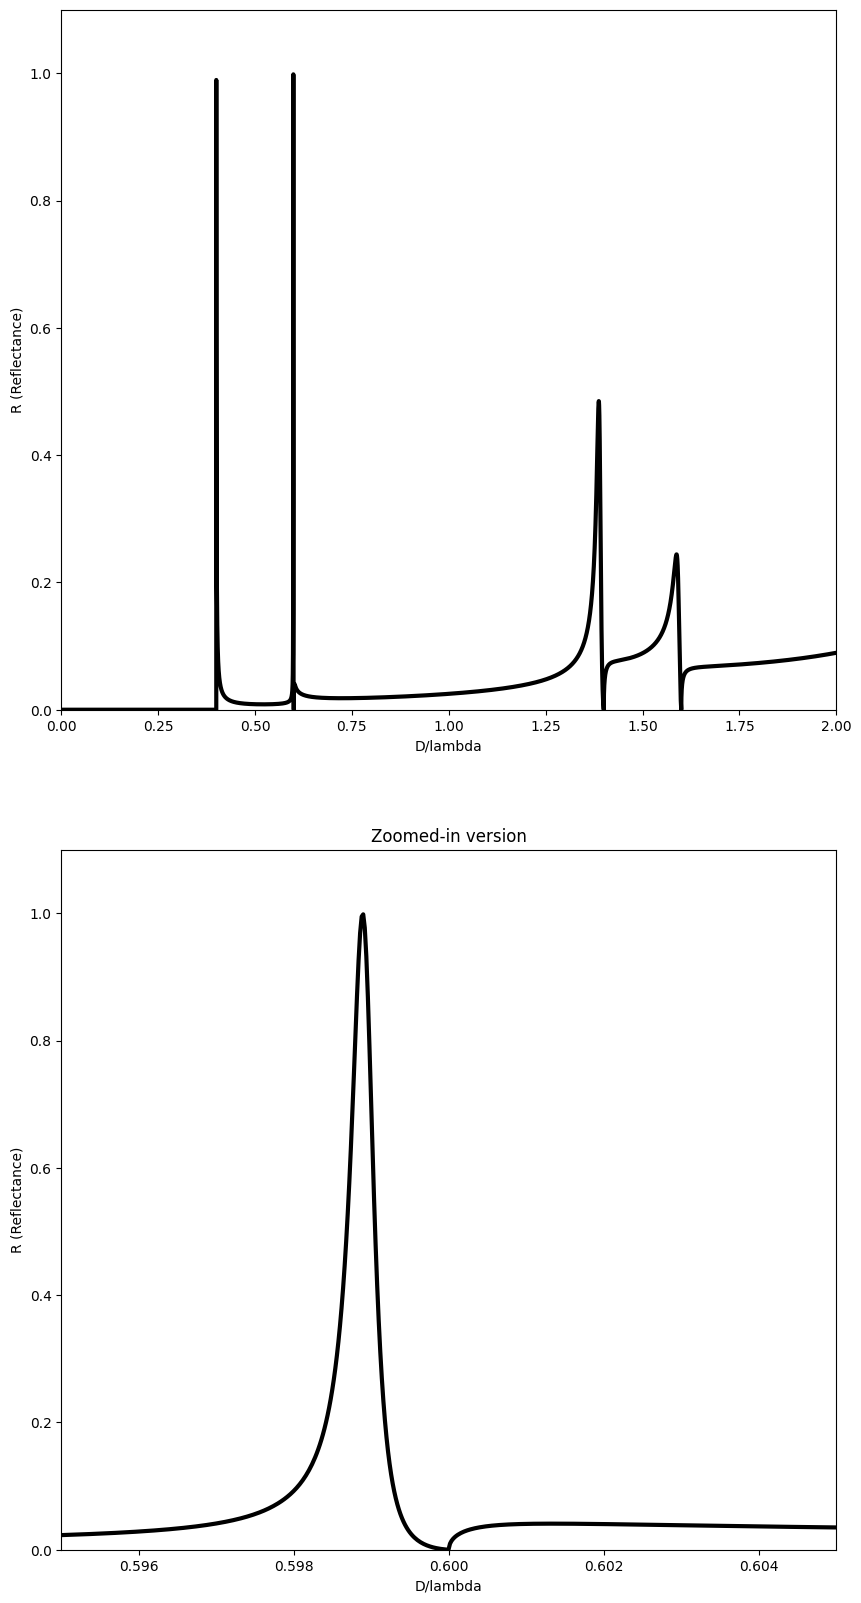

In [194]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 20))
ax1.plot(x_v, R_v, linewidth=3, color="black")
ax1.set_ylim(0, 1.1);
ax1.set_xlim(0, 2);
ax1.set_ylabel("R (Reflectance)")
ax1.set_xlabel("D/lambda");

ax2.plot(x_v, R_v, linewidth=3, color="black")
ax2.set_ylim(0, 1.1);
ax2.set_xlim(0.595, 0.605);
ax2.set_ylabel("R (Reflectance)")
ax2.set_xlabel("D/lambda");
ax2.set_title("Zoomed-in version");